# КИМ 7.1. Оптимизаторы и управление скоростью обучения — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-07-optimizers.ipynb`](./kim-07-optimizers.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В решении используется **PyTorch**. Все эксперименты проводят на одном
разбиении Fashion-MNIST и начинают с одной и той же копии начальных весов. Это
важно: иначе различия случайной инициализации и порядка батчей можно ошибочно
принять за различия оптимизаторов.

Полный набор экспериментов занимает несколько минут на современной видеокарте и
дольше на CPU. Число эпох намеренно невелико, но Adam/AdamW обычно успевают
достичь test accuracy около 0.88 (результат немного зависит от версий библиотек и
оборудования).

---
## Часть А. Сравнение оптимизаторов

### 0. Импорт, выбор устройства и воспроизводимость

In [1]:
import copy
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

%matplotlib inline

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Детерминированность важнее небольшой прибавки скорости в учебном сравнении.
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print(f"Устройство: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Устройство: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


`torch.manual_seed` фиксирует генератор CPU, а
`torch.cuda.manual_seed_all` — генераторы CUDA. Детерминированные алгоритмы
снижают разброс повторных запусков. Полная побитовая воспроизводимость между
разными версиями PyTorch, CUDA и разным оборудованием всё же не гарантируется.

### 1. Загрузка и фиксированное разбиение Fashion-MNIST

In [2]:
# ToTensor переводит uint8-пиксели в float32 и масштабирует их в [0, 1].
# Затем используем известные среднее и стандартное отклонение Fashion-MNIST.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

data_root = Path("data")
full_train = datasets.FashionMNIST(
    root=data_root, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=data_root, train=False, download=True, transform=transform
)

# Одно разбиение 50 000 / 10 000 используется во всех экспериментах.
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train, [50_000, 10_000], generator=split_generator
)

BATCH_SIZE = 512
NUM_WORKERS = min(2, os.cpu_count() or 1)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

def make_loader(dataset, *, shuffle, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
    )

# Для каждого запуска train loader создаётся заново с тем же seed. Поэтому
# оптимизаторы видят одинаковый порядок объектов. Val/test не перемешиваются.
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)
print(len(train_dataset), len(val_dataset), len(test_dataset))

50000 10000 10000


Метки остаются целыми индексами классов от 0 до 9: one-hot encoding
для `nn.CrossEntropyLoss` не нужен.

### 2. Общая MLP и одинаковые начальные веса

In [3]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.layers(x)

def build_model():
    return FashionMLP()

# Эту единственную инициализацию копируем перед каждым экспериментом.
set_seed()
initial_model = build_model()
INITIAL_WEIGHTS = copy.deepcopy(initial_model.state_dict())
del initial_model

def fresh_model():
    # Повторный seed также синхронизирует последовательность масок Dropout.
    set_seed()
    model = build_model()
    model.load_state_dict(INITIAL_WEIGHTS)
    return model.to(DEVICE)

model = fresh_model()
print(model)
del model

FashionMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


Последний слой возвращает **логиты**, поэтому после него нет
`Softmax`. `nn.CrossEntropyLoss` численно устойчиво применяет `LogSoftmax` внутри
себя. Явный `Softmax` перед этой функцией потерь был бы ошибкой.

### 3. Переиспользуемые циклы обучения и оценки

In [4]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    loss_sum = 0.0
    correct = 0
    count = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += batch_size

    return loss_sum / count, correct / count

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()  # отключает Dropout
    loss_sum = 0.0
    correct = 0
    count = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)
        logits = model(inputs)
        loss = criterion(logits, targets)

        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += batch_size

    return loss_sum / count, correct / count

def fit(
    model,
    optimizer,
    epochs,
    *,
    train_loader,
    scheduler=None,
    scheduler_on_plateau=False,
    verbose=False,
):
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [], "lr": [],
    }

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if scheduler is not None:
            if scheduler_on_plateau:
                # ReduceLROnPlateau принимает измеренную validation loss.
                scheduler.step(val_loss)
            else:
                # CosineAnnealingLR делает шаг один раз после каждой эпохи.
                scheduler.step()

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs}: "
                f"loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                f"val_acc={val_acc:.4f}, lr={current_lr:.2e}"
            )

    return history

def print_metrics(rows):
    print(f'{"эксперимент":<24} {"val_loss":>10} {"val_acc":>10} '
          f'{"test_loss":>10} {"test_acc":>10} {"сек":>8}')
    print("-" * 78)
    for row in rows:
        print(
            f'{row["name"]:<24} {row["val_loss"]:>10.4f} '
            f'{row["val_acc"]:>10.4f} {row["test_loss"]:>10.4f} '
            f'{row["test_acc"]:>10.4f} {row["seconds"]:>8.1f}'
        )

Loss суммируется с весом размера батча, а затем делится на число
примеров. Так последний неполный батч не получает непропорционально большой вес.
`model.eval()` обязателен для корректной оценки сети с Dropout.

### 4. SGD, momentum, Adam, AdamW и RMSProp

In [5]:
# Для SGD нужен заметно больший lr, чем для адаптивных методов.
# Значения явно указаны, чтобы протокол можно было воспроизвести.
optimizer_specs = {
    "SGD": (5e-2, lambda params: torch.optim.SGD(params, lr=5e-2)),
    "SGD + momentum": (
        5e-2,
        lambda params: torch.optim.SGD(params, lr=5e-2, momentum=0.9),
    ),
    "Adam": (1e-3, lambda params: torch.optim.Adam(params, lr=1e-3)),
    "AdamW": (
        1e-3,
        lambda params: torch.optim.AdamW(
            params, lr=1e-3, weight_decay=1e-2
        ),
    ),
    "RMSProp": (1e-3, lambda params: torch.optim.RMSprop(params, lr=1e-3)),
}

OPTIMIZER_EPOCHS = 10
optimizer_histories = {}
optimizer_results = []

for name, (lr, make_optimizer) in optimizer_specs.items():
    model = fresh_model()
    optimizer = make_optimizer(model.parameters())
    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)

    started = time.perf_counter()
    history = fit(
        model,
        optimizer,
        OPTIMIZER_EPOCHS,
        train_loader=train_loader,
    )
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    optimizer_histories[name] = history
    optimizer_results.append({
        "name": f"{name} (lr={lr:g})",
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(optimizer_results)

эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
SGD (lr=0.05)                0.3937     0.8619     0.4149     0.8484     48.9
SGD + momentum (lr=0.05)     0.3041     0.8920     0.3327     0.8830     50.2
Adam (lr=0.001)              0.3143     0.8843     0.3392     0.8766     50.7
AdamW (lr=0.001)             0.3122     0.8839     0.3385     0.8774     53.0
RMSProp (lr=0.001)           0.3070     0.8876     0.3297     0.8803     51.7


Тестовый набор оценивается только после обучения и не участвует в
выборе параметров. Для честного сравнения совпадают архитектура, начальные веса,
разбиение, порядок батчей, маски Dropout, batch size и число эпох. Learning rate
указан рядом с названием: алгоритм и его масштаб шага нельзя интерпретировать как
один и тот же фактор.

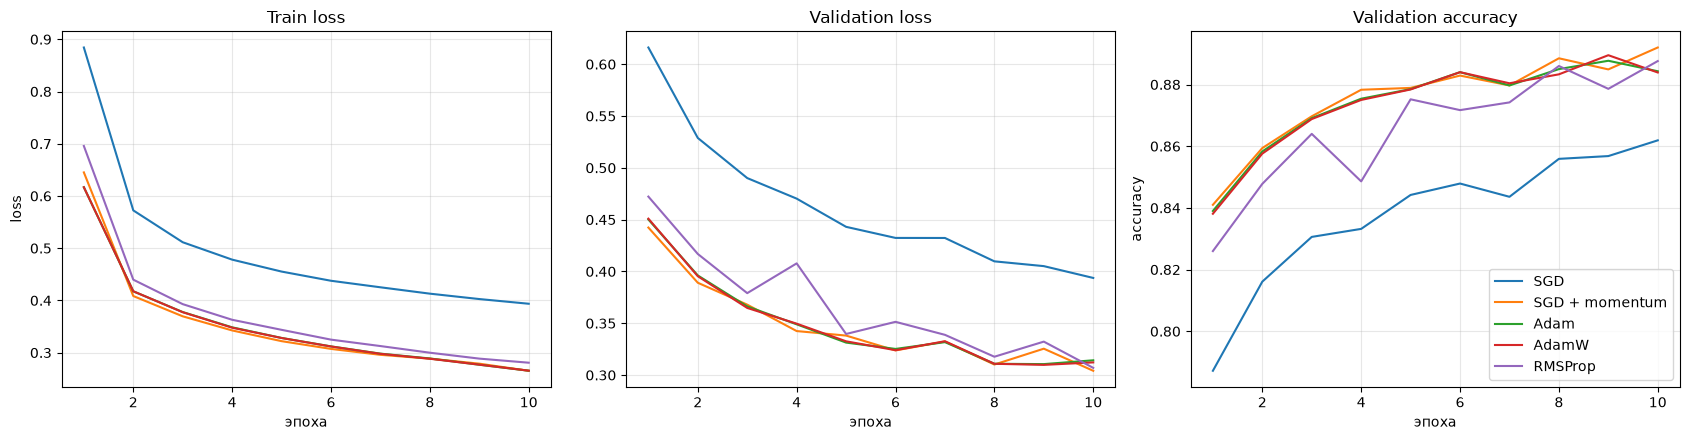

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for name, history in optimizer_histories.items():
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label=name)
    axes[1].plot(epochs, history["val_loss"], label=name)
    axes[2].plot(epochs, history["val_acc"], label=name)

axes[0].set_title("Train loss")
axes[1].set_title("Validation loss")
axes[2].set_title("Validation accuracy")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
axes[0].set_ylabel("loss")
axes[2].set_ylabel("accuracy")
axes[2].legend()
plt.tight_layout()
plt.show()

**Ответ (SGD, momentum и адаптивные методы).** Обычный SGD делает
одинаково масштабированный шаг для всех параметров. Momentum накапливает
экспоненциально сглаженное направление градиента, ускоряет движение вдоль
устойчивого направления и уменьшает колебания.

RMSProp делит шаг каждого параметра на корень из скользящего среднего квадратов
его градиентов. Adam сочетает такую адаптацию с моментом первого порядка. Поэтому
Adam часто быстро достигает хорошего результата без тщательной настройки. AdamW
отделяет weight decay от градиентного шага Adam, благодаря чему L2-подобная
регуляризация имеет более понятное действие. На некоторых задачах хорошо
настроенный SGD с momentum обобщает лучше, но обычно требует больше эпох.

---
## Часть Б. Управление скоростью обучения

### 5. Сравнение learning rate: от расходящегося до слишком малого

эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
Adam, lr=1                   5.2992     0.2049    17.3287     0.2038     30.9
Adam, lr=0.01                0.3677     0.8714     0.3884     0.8652     29.1
Adam, lr=0.001               0.3252     0.8840     0.3492     0.8762     29.5
Adam, lr=0.0001              0.4506     0.8454     0.4666     0.8335     29.9
Большой lr нестабилен: peak train loss=865.9687 против 0.6168; best val accuracy=0.2205 против 0.8840.


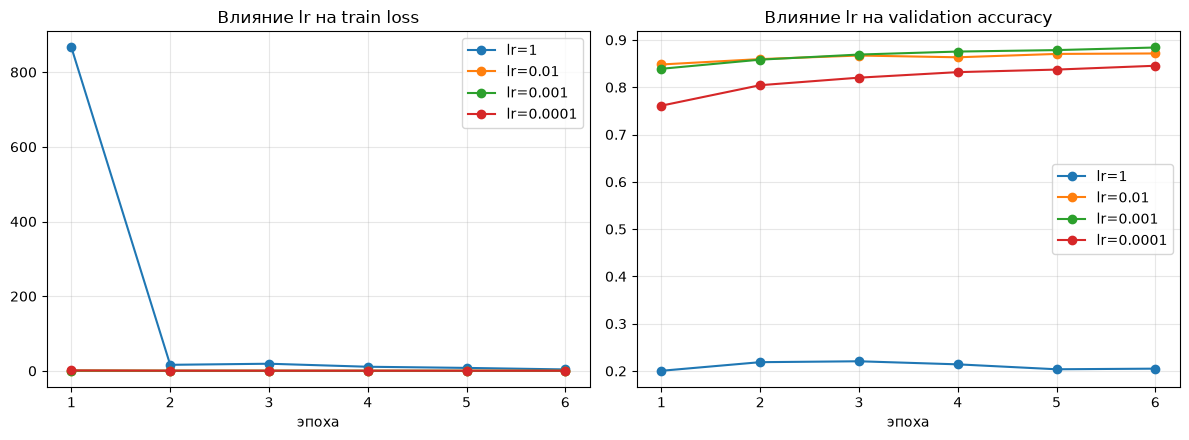

In [7]:
# lr=1 добавлен как заведомо слишком большой диагностический режим.
# Три значения из КИМ сохраняются для сравнения практически применимых режимов.
LEARNING_RATES = [1.0, 1e-2, 1e-3, 1e-4]
LR_EPOCHS = 6
lr_histories = {}
lr_results = []

for lr in LEARNING_RATES:
    model = fresh_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)

    started = time.perf_counter()
    history = fit(model, optimizer, LR_EPOCHS, train_loader=train_loader)
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    lr_histories[lr] = history
    lr_results.append({
        "name": f"Adam, lr={lr:g}",
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(lr_results)

large_lr_history = lr_histories[1.0]
reference_history = lr_histories[1e-3]
large_lr_peak_loss = max(large_lr_history["train_loss"])
reference_peak_loss = max(reference_history["train_loss"])
large_lr_best_val_acc = max(large_lr_history["val_acc"])
reference_best_val_acc = max(reference_history["val_acc"])
large_lr_is_unstable = (
    large_lr_peak_loss > 10 * reference_peak_loss
    and large_lr_best_val_acc + 0.15 < reference_best_val_acc
)
assert large_lr_is_unstable, (
    "Диагностический большой lr не показал нестабильность; "
    "увеличьте верхнее значение для текущей версии optimizer."
)
print(
    "Большой lr нестабилен: "
    f"peak train loss={large_lr_peak_loss:.4f} против "
    f"{reference_peak_loss:.4f}; best val accuracy="
    f"{large_lr_best_val_acc:.4f} против {reference_best_val_acc:.4f}."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for lr, history in lr_histories.items():
    epochs = range(1, LR_EPOCHS + 1)
    axes[0].plot(epochs, history["train_loss"], marker="o", label=f"lr={lr:g}")
    axes[1].plot(epochs, history["val_acc"], marker="o", label=f"lr={lr:g}")

axes[0].set_title("Влияние lr на train loss")
axes[1].set_title("Влияние lr на validation accuracy")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

Проверка над измеренными кривыми подтверждает нестабильность
`lr=1`: loss резко возрастает и/или качество остаётся существенно ниже
контрольного `lr=1e-3`. `lr=1e-4` даёт плавное, но медленное обучение, а
`lr=1e-2` показывает пограничный режим. Для этой архитектуры разумной отправной
точкой служит `1e-3`; вывод подтверждается напечатанными числами и `assert`, а не
только ожидаемым поведением.

### 6. ReduceLROnPlateau и CosineAnnealingLR

In [8]:
SCHEDULER_EPOCHS = 20
scheduler_histories = {}
scheduler_results = []

for strategy in ["constant", "ReduceLROnPlateau", "CosineAnnealingLR"]:
    model = fresh_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if strategy == "ReduceLROnPlateau":
        # Параметры совпадают с протоколом КИМ.
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
            threshold=5e-3,
            threshold_mode="abs",
            min_lr=1e-5,
        )
        scheduler_on_plateau = True
    elif strategy == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=SCHEDULER_EPOCHS, eta_min=1e-5
        )
        scheduler_on_plateau = False
    else:
        scheduler = None
        scheduler_on_plateau = False

    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)
    started = time.perf_counter()
    history = fit(
        model,
        optimizer,
        SCHEDULER_EPOCHS,
        train_loader=train_loader,
        scheduler=scheduler,
        scheduler_on_plateau=scheduler_on_plateau,
    )
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    scheduler_histories[strategy] = history
    scheduler_results.append({
        "name": strategy,
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(scheduler_results)

plateau_lrs = scheduler_histories["ReduceLROnPlateau"]["lr"]
assert min(plateau_lrs) < plateau_lrs[0], (
    "ReduceLROnPlateau не успел уменьшить lr; увеличьте число эпох."
)

best_optimizer_result = max(
    optimizer_results, key=lambda row: row["val_acc"]
)
best_scheduler_result = max(
    scheduler_results, key=lambda row: row["val_acc"]
)
print(
    "Победитель сравнения оптимизаторов по val_accuracy:",
    best_optimizer_result["name"],
    f"({best_optimizer_result['val_acc']:.4f})",
)
print(
    "Победитель сравнения стратегий по val_accuracy:",
    best_scheduler_result["name"],
    f"({best_scheduler_result['val_acc']:.4f})",
)

эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
constant                     0.2986     0.8941     0.3252     0.8885    100.2
ReduceLROnPlateau            0.2908     0.8971     0.3131     0.8917     97.9
CosineAnnealingLR            0.2861     0.8965     0.3097     0.8899     97.2
Победитель сравнения оптимизаторов по val_accuracy: SGD + momentum (lr=0.05) (0.8920)
Победитель сравнения стратегий по val_accuracy: ReduceLROnPlateau (0.8971)


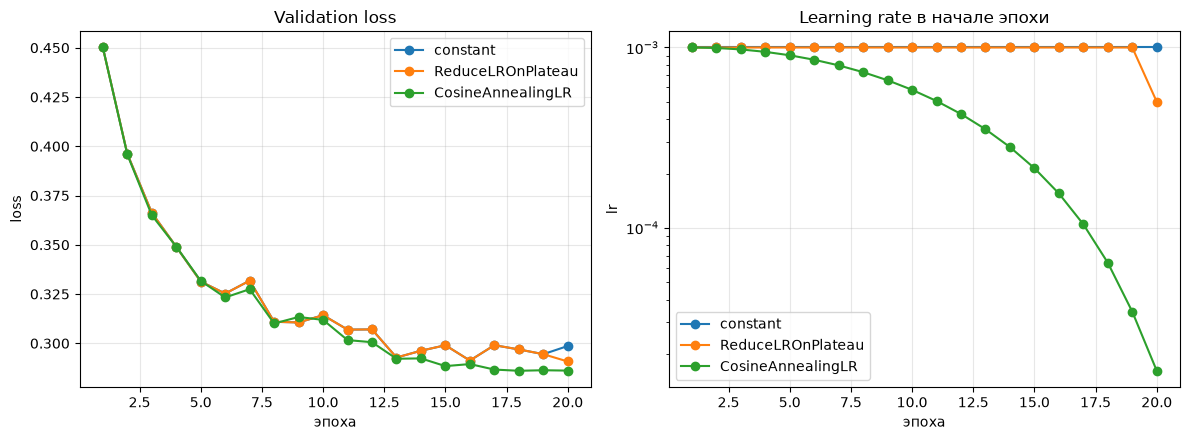

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for strategy, history in scheduler_histories.items():
    epochs = range(1, SCHEDULER_EPOCHS + 1)
    axes[0].plot(epochs, history["val_loss"], marker="o", label=strategy)
    axes[1].plot(epochs, history["lr"], marker="o", label=strategy)

axes[0].set_title("Validation loss")
axes[0].set_xlabel("эпоха")
axes[0].set_ylabel("loss")
axes[1].set_title("Learning rate в начале эпохи")
axes[1].set_xlabel("эпоха")
axes[1].set_ylabel("lr")
axes[1].set_yscale("log")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

`ReduceLROnPlateau` не знает номер «правильной» эпохи: после каждой
эпохи ему явно передаётся измеренный `val_loss` вызовом
`scheduler.step(val_loss)`. Если улучшения нет `patience` эпох, lr умножается на
`factor`. Косинусный scheduler, напротив, заранее задаёт плавную траекторию от
начального lr к `eta_min` и вызывается как `scheduler.step()` без метрики.

Уменьшение шага около минимума позволяет точнее настраивать веса и меньше
перескакивать через хорошие области. Но scheduler не гарантирует улучшение test
accuracy: это проверяется экспериментом.

---
## Часть В. Ручная ранняя остановка

### 7. Early stopping с `patience=15` и восстановлением весов

Для наглядного plateau берётся фиксированная подвыборка из 5 000 train-объектов,
а validation остаётся полной. На малом train модель быстрее переобучается, поэтому
разрыв train/validation и экономия эпох видны без искусственного отключения
optimizer. Как и в формулировке КИМ, любое строгое улучшение `val_accuracy`
сбрасывает patience; отдельный `min_delta` не вводится.

In [10]:
EARLY_STOP_MAX_EPOCHS = 80
EARLY_STOP_PATIENCE = 15
EARLY_STOP_TRAIN_SIZE = 5_000

early_train_dataset = Subset(train_dataset, range(EARLY_STOP_TRAIN_SIZE))

model = fresh_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = make_loader(early_train_dataset, shuffle=True, seed=SEED)

early_history = {
    "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
}
best_val_acc = -float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, EARLY_STOP_MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)
    early_history["train_loss"].append(train_loss)
    early_history["train_acc"].append(train_acc)
    early_history["val_loss"].append(val_loss)
    early_history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        # state_dict содержит ссылки на текущие тензоры, поэтому нужна deep copy.
        best_weights = copy.deepcopy(model.state_dict())
        marker = " <- лучшие веса сохранены"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(
        f"epoch {epoch:02d}: train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, "
        f"val_acc={val_acc:.4f}{marker}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Ранняя остановка после эпохи {epoch}")
        break
else:
    print("Критерий остановки не сработал до максимального числа эпох")

epochs_run = len(early_history["val_acc"])
last_val_acc = early_history["val_acc"][-1]
assert epochs_run < EARLY_STOP_MAX_EPOCHS, (
    "EarlyStopping не сработал до лимита; увеличьте лимит диагностического запуска."
)
model.load_state_dict(best_weights)
restored_val_loss, restored_val_acc = evaluate(model, val_loader)
test_loss, test_acc = evaluate(model, test_loader)
assert abs(restored_val_acc - max(early_history["val_acc"])) < 1e-12

print(f"Выполнено эпох: {epochs_run} из {EARLY_STOP_MAX_EPOCHS}")
print(f"Сэкономлено эпох: {EARLY_STOP_MAX_EPOCHS - epochs_run}")
print(f"Лучшая эпоха: {best_epoch}")
print(f"До восстановления: val_accuracy={last_val_acc:.4f}")
print(f"Validation: loss={restored_val_loss:.4f}, accuracy={restored_val_acc:.4f}")
print(f"Test:       loss={test_loss:.4f}, accuracy={test_acc:.4f}")

epoch 01: train_acc=0.5680, val_loss=0.7910, val_acc=0.7159 <- лучшие веса сохранены


epoch 02: train_acc=0.7244, val_loss=0.6286, val_acc=0.7750 <- лучшие веса сохранены


epoch 03: train_acc=0.7722, val_loss=0.5651, val_acc=0.8054 <- лучшие веса сохранены


epoch 04: train_acc=0.7972, val_loss=0.5296, val_acc=0.8110 <- лучшие веса сохранены


epoch 05: train_acc=0.8060, val_loss=0.5141, val_acc=0.8157 <- лучшие веса сохранены


...

epoch 61: train_acc=0.9776, val_loss=0.4805, val_acc=0.8603


epoch 62: train_acc=0.9806, val_loss=0.4876, val_acc=0.8592


epoch 63: train_acc=0.9814, val_loss=0.4796, val_acc=0.8595


epoch 64: train_acc=0.9824, val_loss=0.4935, val_acc=0.8593
Ранняя остановка после эпохи 64


Выполнено эпох: 64 из 80
Сэкономлено эпох: 16
Лучшая эпоха: 49
До восстановления: val_accuracy=0.8593
Validation: loss=0.4499, accuracy=0.8619
Test:       loss=0.4748, accuracy=0.8499


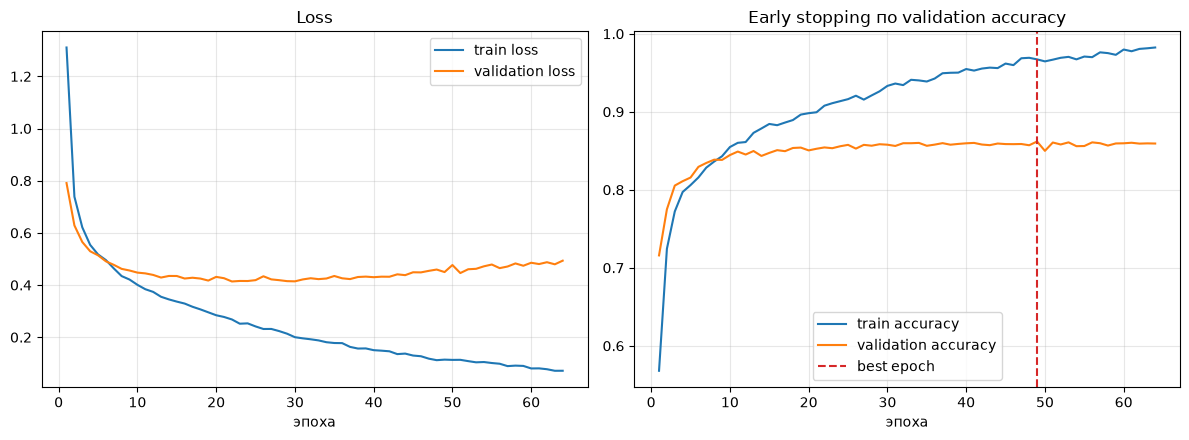

In [11]:
epochs = range(1, epochs_run + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs, early_history["train_loss"], label="train loss")
axes[0].plot(epochs, early_history["val_loss"], label="validation loss")
axes[1].plot(epochs, early_history["train_acc"], label="train accuracy")
axes[1].plot(epochs, early_history["val_acc"], label="validation accuracy")
axes[1].axvline(best_epoch, color="tab:red", linestyle="--", label="best epoch")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
    axis.legend()
axes[0].set_title("Loss")
axes[1].set_title("Early stopping по validation accuracy")
plt.tight_layout()
plt.show()

**Почему нужен `copy.deepcopy`.** Значения в обычном
`model.state_dict()` связаны с тензорами модели и продолжили бы изменяться при
следующих шагах оптимизатора. Глубокая копия фиксирует снимок лучшей эпохи.
Early stopping с требуемым `patience=15` завершает обучение после серии эпох без
значимого улучшения и затем `load_state_dict(best_weights)` возвращает этот
снимок. Напечатанное число сэкономленных эпох и растущий разрыв train/validation
показывают соответственно экономию и предотвращение продолжения переобучения.

---
## 8. Вывод

- Сравнивать оптимизаторы следует при одинаковых данных, инициализации, порядке
  батчей и бюджете обучения; learning rate нужно указывать явно.
- Для этой небольшой MLP Adam и AdamW обычно быстрее выходят примерно на 0.88,
  а SGD особенно выигрывает от momentum и/или большего числа эпох.
- `lr=1e-3` — разумная отправная точка для Adam; диагностический `lr=1` измеримо
  нестабилен, а `lr=1e-4` сходится медленно.
- `ReduceLROnPlateau` реагирует на фактическую validation loss, а
  `CosineAnnealingLR` меняет lr по заранее заданной траектории.
- Ручной early stopping должен хранить независимую копию лучших весов и
  восстанавливать её перед итоговой оценкой.

Конкретные победители оптимизатора и стратегии напечатаны выше по измеренной
validation accuracy; ожидаемые тенденции не заменяют это сравнение.